**Random forest** is an ensemble learning method for classification, regression, and other tasks that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. Random forests correct for decision trees' habit of overfitting to their training set.
The random forest algorithm was developed by Leo Breiman and Adele Cutler. It is widely used in various applications due to its simplicity, flexibility, and effectiveness. The key idea behind random forests is to create a "forest" of decision trees, where each tree is trained on a random subset of the data and features. This randomness helps to reduce overfitting and improve the generalization of the model.
Here is a simple implementation of a random forest classifier in Python

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error



In [13]:
# load dataset

df = sns.load_dataset('tips') 

In [14]:
# Encode feature 
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype == 'object' or df[i].dtype == 'category':
        df[i] = le.fit_transform(df[i])

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [15]:
# split variable
x = df.drop('sex', axis=1)
y = df['sex']

In [16]:
# TRAIN TEST SPLIT 

x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
# create a model and train and pred
model = RandomForestClassifier(n_estimators=200)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)



              precision    recall  f1-score   support

           0       0.50      0.37      0.42        19
           1       0.66      0.77      0.71        30

    accuracy                           0.61        49
   macro avg       0.58      0.57      0.57        49
weighted avg       0.60      0.61      0.60        49



<Axes: >

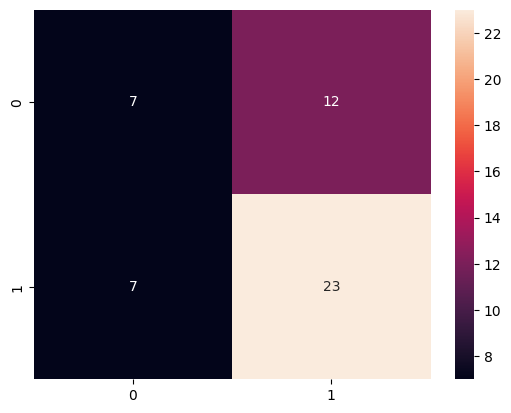

In [18]:
# evalute the model 
print(classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True)